# Amazon Reviews - Graph-Based Analysis & Visualizations

## Graph-Based Analysis & Visualizations

Uses `graph_logic/models.py` and `graph_logic/analysis.py` to compute retention rates, high-retention categories, and expansion pathways — then visualizes them.

> **Note**: Graph is built on a sampled subset of users (configurable via `SAMPLE_USERS` below) to keep runtime manageable. Set to `None` to use the full dataset.

In [1]:
import pandas as pd
import numpy as np
import sys
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLEANED_DATA_PATH = PROJECT_ROOT / "data/cleaned/cleaned_reviews.csv"

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Path: {CLEANED_DATA_PATH}")
print(f"File exists: {CLEANED_DATA_PATH.exists()}")

Project Root: /Users/tylertran/Documents/umich/courses/w26_project
Data Path: /Users/tylertran/Documents/umich/courses/w26_project/data/cleaned/cleaned_reviews.csv
File exists: True


In [2]:
# Load cleaned data
df = pd.read_csv(CLEANED_DATA_PATH)
df["date"] = pd.to_datetime(df["date"], format="ISO8601")

print(f"Loaded {len(df):,} records")
print(f"Shape: {df.shape}")

Loaded 2,523,881 records
Shape: (2523881, 12)


In [3]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from graph_logic.models import Graph
from graph_logic.analysis import (
    identify_high_retention_categories,
    compute_all_expansion_pathways,
    generate_summary_report,
)

print("graph_logic modules loaded.")

graph_logic modules loaded.


In [4]:
# --- Sample users for graph build (set SAMPLE_USERS=None for full dataset) ---
SAMPLE_USERS = 500_000

rng = np.random.default_rng(42)
all_user_ids = df['user_id'].unique()

if SAMPLE_USERS is not None and SAMPLE_USERS < len(all_user_ids):
    sampled_ids = rng.choice(all_user_ids, size=SAMPLE_USERS, replace=False)
else:
    sampled_ids = all_user_ids

df_sample = df[df['user_id'].isin(sampled_ids)].copy()
df_sample['date'] = pd.to_datetime(df_sample['date'], format='ISO8601')

print(f"Building graph from {len(df_sample):,} reviews ({len(sampled_ids):,} users)...")
graph = Graph.from_dataframe(df_sample)
print(graph)

Building graph from 688,961 reviews (500,000 users)...
Graph(users=500000, categories=['Cell_Phones_and_Accessories', 'Electronics', 'Software', 'Video_Games'], interaction_nodes=685259, interaction_edges=688961, transition_edges=12)


In [5]:
print(generate_summary_report(graph))

RETENTION RATES BY CATEGORY
  Software                            10.51%  (4832 observable users)
  Electronics                         10.04%  (237280 observable users)
  Cell_Phones_and_Accessories          7.36%  (130823 observable users)
  Video_Games                          5.70%  (23199 observable users)

HIGH-RETENTION CATEGORIES (top quartile, ≥30 users)
  * Software  (10.51%)

EXPANSION PATHWAYS  (A → B where B is high-retention)
  Video_Games                         → Software                             -1.29%
  Cell_Phones_and_Accessories         → Software                             -1.85%
  Electronics                         → Software                             -3.10%



### Retention Rates by Category

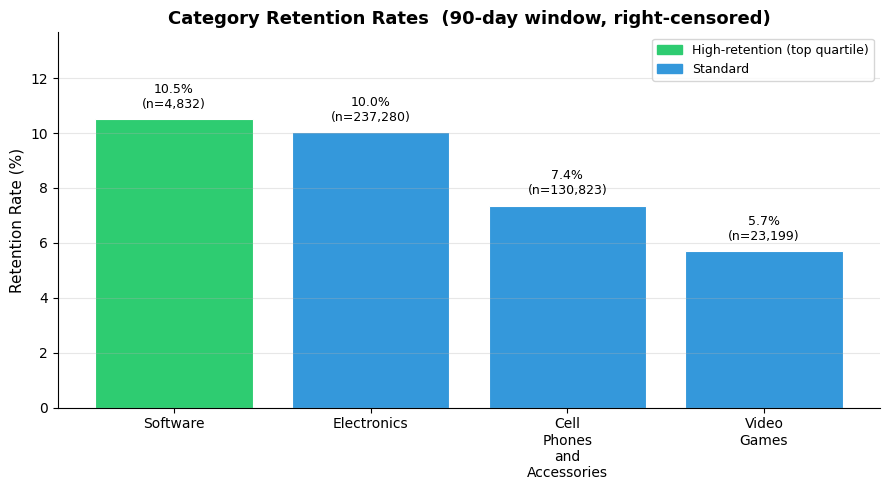

In [6]:
high_ret = identify_high_retention_categories(graph.categories)

cats_sorted = sorted(graph.categories.items(), key=lambda kv: kv[1].retention_rate, reverse=True)
names   = [c[0].replace('_', '\n') for c in cats_sorted]
rates   = [c[1].retention_rate * 100 for c in cats_sorted]
obs     = [c[1].observable_user_count() for c in cats_sorted]
colors  = ['#2ecc71' if c[0] in high_ret else '#3498db' for c in cats_sorted]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names, rates, color=colors, edgecolor='white', linewidth=0.8)

for bar, rate, n_obs in zip(bars, rates, obs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{rate:.1f}%\n(n={n_obs:,})', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Retention Rate (%)', fontsize=11)
ax.set_title('Category Retention Rates  (90-day window, right-censored)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(rates) * 1.3 if rates else 10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='High-retention (top quartile)'),
    mpatches.Patch(color='#3498db', label='Standard'),
], loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

### Category Transition Graph

Nodes = categories. Edge A → B exists when a user reviewed in A and later reviewed in B. Edge weight = number of distinct users who made that transition.

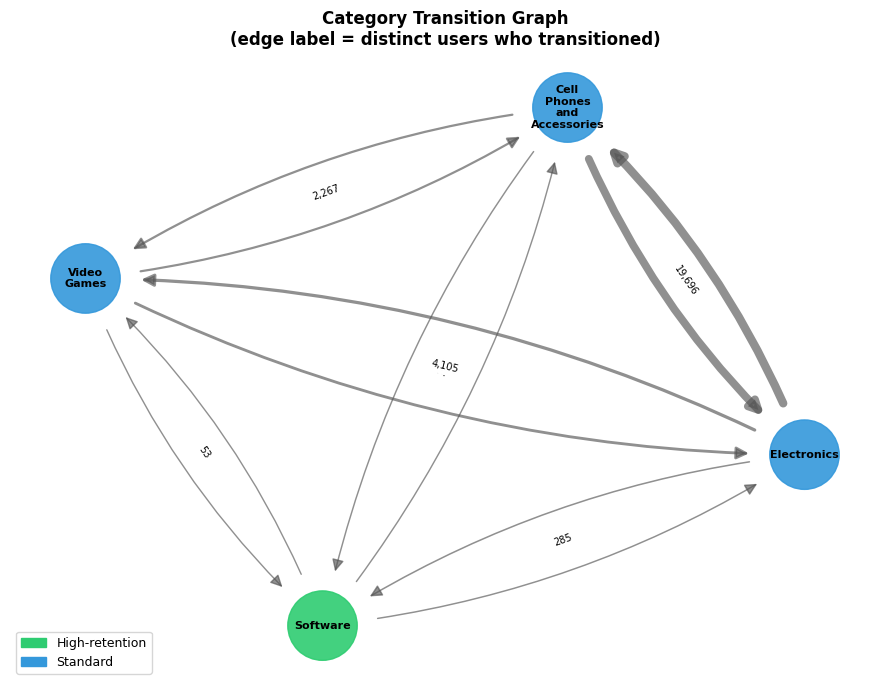

In [7]:
import networkx as nx

G = graph.transition_graph
pos = nx.spring_layout(G, seed=42, k=2.5)

edge_weights = [G[u][v]['user_count'] for u, v in G.edges()]
max_w = max(edge_weights) if edge_weights else 1
norm_widths = [1 + 5 * (w / max_w) for w in edge_weights]

node_colors = ['#2ecc71' if n in high_ret else '#3498db' for n in G.nodes()]
short_labels = {n: n.replace('_', '\n') for n in G.nodes()}

fig, ax = plt.subplots(figsize=(9, 7))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2500, ax=ax, alpha=0.9)
nx.draw_networkx_labels(G, pos, labels=short_labels, font_size=8, font_weight='bold', ax=ax)
nx.draw_networkx_edges(
    G, pos, width=norm_widths, alpha=0.65, edge_color='#555',
    connectionstyle='arc3,rad=0.12', arrows=True, arrowsize=18, ax=ax,
    min_source_margin=40, min_target_margin=40,
)
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels={(u, v): f"{G[u][v]['user_count']:,}" for u, v in G.edges()},
    font_size=7, ax=ax,
)

ax.set_title('Category Transition Graph\n(edge label = distinct users who transitioned)',
             fontsize=12, fontweight='bold')
ax.axis('off')
ax.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='High-retention'),
    mpatches.Patch(color='#3498db', label='Standard'),
], loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

### Expansion Pathway Heatmap

`ExpansionDifference(A → B)` = P(reviewing high-retention category B within 90 days | first category = A) − baseline P(B | first ≠ A). Green = above-baseline expansion, red = below.

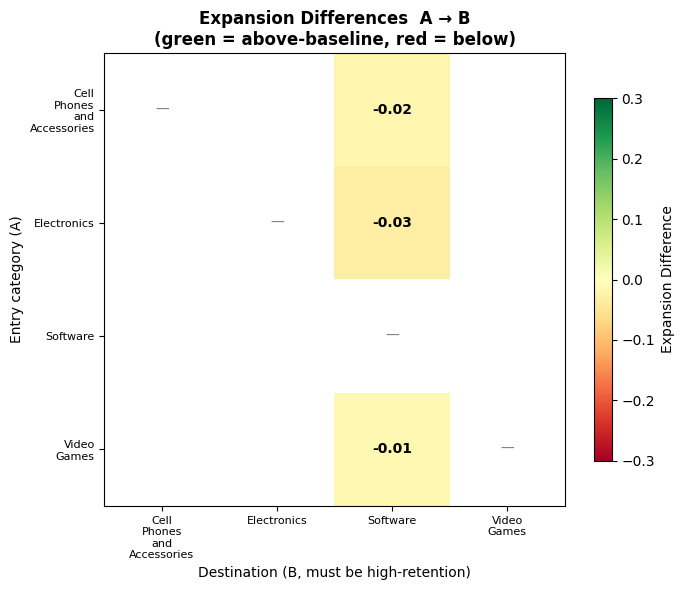

In [8]:
pathways = compute_all_expansion_pathways(graph.users, high_ret)

if not pathways:
    print("No expansion pathways — check high-retention set and cohort sizes.")
else:
    all_cats_list = sorted(graph.categories.keys())
    n = len(all_cats_list)
    cat_idx = {c: i for i, c in enumerate(all_cats_list)}

    matrix = np.full((n, n), np.nan)
    for (entry, dest), diff in pathways.items():
        matrix[cat_idx[entry], cat_idx[dest]] = diff

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=-0.3, vmax=0.3, aspect='auto')

    short_names = [c.replace('_', '\n') for c in all_cats_list]
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(short_names, fontsize=8)
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel('Destination (B, must be high-retention)', fontsize=10)
    ax.set_ylabel('Entry category (A)', fontsize=10)
    ax.set_title('Expansion Differences  A → B\n(green = above-baseline, red = below)', fontsize=12, fontweight='bold')

    for i in range(n):
        for j in range(n):
            val = matrix[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:+.2f}', ha='center', va='center', fontsize=10, color='black', fontweight='bold')
            elif i == j:
                ax.text(j, i, '—', ha='center', va='center', fontsize=10, color='gray')

    plt.colorbar(im, ax=ax, label='Expansion Difference', shrink=0.8)
    plt.tight_layout()
    plt.show()

## Machine Learning Analysis

> **Note**: Retention prediction was removed from this project on 2026-04-16. See git history for prior implementation.

The remaining ML analysis covers **User Clustering** only — see cells below.

### 2. User Clustering

Segment users into behavioral types based on review patterns across all categories.

In [14]:
# Build user features
user_features = build_user_features(graph, min_reviews=1)
print(f'User feature matrix: {user_features.shape}')
print(f'\nFeature summary:')
print(user_features.drop(columns=['user_id']).describe().round(2))

User feature matrix: (500000, 13)

Feature summary:
       total_review_count  category_count  avg_rating  rating_std  \
count           500000.00       500000.00   500000.00   500000.00   
mean                 1.38            1.10        3.82        0.11   
std                  1.13            0.32        1.56        0.38   
min                  1.00            1.00        1.00        0.00   
25%                  1.00            1.00        3.00        0.00   
50%                  1.00            1.00        5.00        0.00   
75%                  1.00            1.00        5.00        0.00   
max                 72.00            4.00        5.00        2.00   

       total_helpful_votes  avg_helpful_votes  active_days  time_span_days  \
count            500000.00          500000.00    500000.00       500000.00   
mean                  0.70               0.52         1.15            4.27   
std                   6.28               4.88         0.52           16.39   
min           

Best k by silhouette: 2


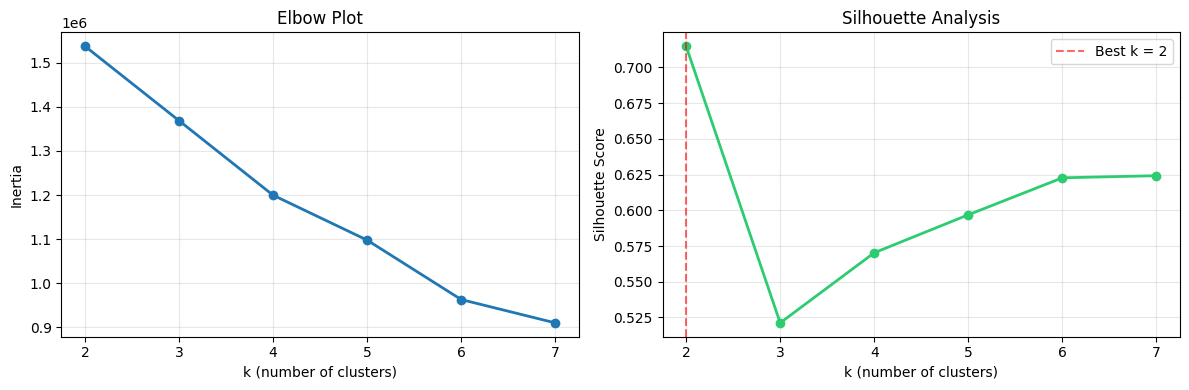

In [15]:
# Find optimal k via elbow + silhouette analysis
k_result = find_optimal_k(user_features, k_range=range(2, 8))
print(f'Best k by silhouette: {k_result["best_k"]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_elbow(k_result, ax=axes[0])
plot_silhouette(k_result, ax=axes[1])
plt.tight_layout()
plt.show()

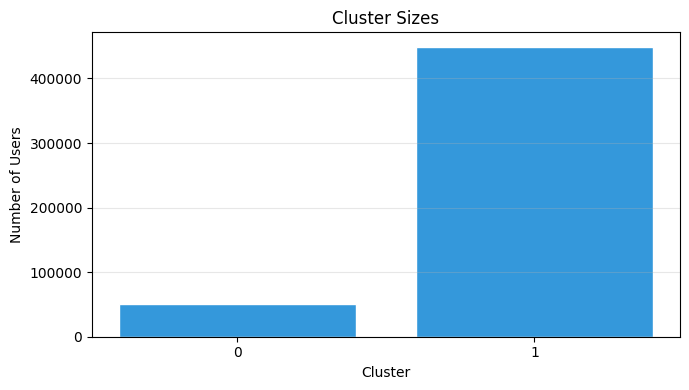


=== Cluster Profiles ===
                     label    size  total_review_count  category_count  avg_rating  time_span_days  is_multi_category
cluster                                                                                                              
0        Category explorer   50978            3.443431        1.981888    4.170469       25.686777       9.233923e-01
1             One-and-done  449022            1.147316        1.000000    3.775335        1.915660      -2.365330e-13


In [16]:
# Fit K-means with best k
cluster_result = train_clustering(user_features, n_clusters=k_result['best_k'])

# Cluster sizes
fig, ax = plt.subplots(figsize=(7, 4))
plot_cluster_sizes(cluster_result, ax=ax)
plt.tight_layout()
plt.show()

# Cluster profiles
profiles = characterize_clusters(cluster_result)
print('\n=== Cluster Profiles ===')
print(profiles[['label', 'size', 'total_review_count', 'category_count',
                 'avg_rating', 'time_span_days', 'is_multi_category']].to_string())

### Key Findings

**User Clustering:**
- Distinct reviewer archetypes emerge from behavioral features
- Cluster profiles help characterize the user base beyond simple review counts